# Adding more data and compare measures

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import os
from itertools import product

from tqdm import tqdm

In [2]:
# Moving to parent directory to import from CDFD and other_helpers
current_dir = os.getcwd()
os.chdir("..")
from CDFD import get_circularity, CDFD
from other_helpers import  uniform_multigraph, in_cycle_ratio, trophic_incoherence,finn_cycling_index
from scipy.sparse import lil_array, csr_array, diags_array, coo_array, identity, csr_matrix, eye
from scipy.sparse.linalg import splu
# Moving back to original directory
os.chdir(current_dir)

### government data

In [3]:
records = []
base_dir = 'data_government'

for sub in tqdm(os.listdir(base_dir)):
    folder = os.path.join(current_dir,base_dir, sub)
    if not os.path.isdir(folder):
        continue
    if 'edges.txt' not in os.listdir(folder):
        continue

    # --- load edges only; nodes inferred automatically ---
    edges = pd.read_csv(
        os.path.join(folder,'edges.txt'),
        sep='\t', engine='python'
    )
    G = nx.DiGraph()
    for _, row in edges.iterrows():
        u, v = int(row.Src), int(row.Trg)
        G.add_edge(u, v, weight=float(row.LinkCount))

    # --- infer node list (sorted for reproducibility) ---
    nodes = sorted(G.nodes())

    # --- compute measures ---
    incoh    = trophic_incoherence(G)
    incyc    = in_cycle_ratio(G)
    W        = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    x        = W.sum(axis=0)
    fci      = finn_cycling_index(csr_matrix(W))
    C1, D1   = CDFD(G, solution_method='min_cost_pulp')
    circ_max = get_circularity(C1, D1)
    C2, D2   = CDFD(G, solution_method='BFF')
    circ_bff = get_circularity(C2, D2)

    records.append({
        'folder':         sub,
        'incoherence':    incoh,
        'in_cycle_ratio': incyc,
        'fci':            fci,
        'circ_max':       circ_max,
        'circ_bff':       circ_bff
    })


  0%|                                                                                                                                      | 0/55 [00:00<?, ?it/s]/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/d3a7ff4ad1084bd69f824386b803f151-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/d3a7ff4ad1084bd69f824386b803f151-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 1045 COLUMNS
At line 30977 RHS
At line 32018 BOUNDS
At line 41996 ENDATA
Problem MODEL has 1040 rows, 9977 columns and 19954 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 595 (-445) rows, 7162 (-2815) columns and 14324 (-5630) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.0811993e-05 ( 0.0056497849%) - largest zero change 4.6850264e-05
0  Obj 530894.38 Primal inf 88408.286 (586)
86  Obj 584957.37 Primal i

  2%|██▎                                                                                                                           | 1/55 [00:01<01:24,  1.56s/it]/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
  4%|████▌                                                                                                                         | 2/55 [00:01<00:40,  1.32it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/2d59a493aa104d159459f50d48ca17bb-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/2d59a493aa104d159459f50d48ca17bb-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 352 COLUMNS
At line 4544 RHS
At line 4892 BOUNDS
At line 6290 ENDATA
Problem MODEL has 347 rows, 1397 columns and 2794 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 136 (-211) rows, 876 (-521) columns and 1752 (-1042) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 5.8176759e-05 ( 0.0056447641%) - largest zero change 0
0  Obj 81693.356 Primal inf 6494.8043 (135)
46  Obj 85417.332 Primal inf 927.60137 (109)
12

/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


...

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/5ad2d9fbf6ba4afe95f8a826018608bf-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/5ad2d9fbf6ba4afe95f8a826018608bf-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 372 COLUMNS
At line 14305 RHS
At line 14673 BOUNDS
At line 19318 ENDATA
Problem MODEL has 367 rows, 4644 columns and 9288 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 210 (-157) rows, 3135 (-1509) columns and 6270 (-3018) elements
Perturbing problem by 0.001% of 2 - largest nonzero change 5.8488022e-05 ( 0.0055962401%) - largest zero change 0
0  Obj 238472.42 Primal inf 57994.207 (209)
79  Obj 275761.92 Primal inf 9307.1015 (17

 95%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏      | 52/55 [01:04<00:02,  1.37it/s]/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/b20f53783315472ebea4a1d7fd9ec254-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/b20f53783315472ebea4a1d7fd9ec254-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 3590 COLUMNS
At line 156285 RHS
At line 159871 BOUNDS
At line 210770 ENDATA
Problem MODEL has 3585 rows, 50898 columns and 101796 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 1885 (-1700) rows, 39324 (-11574) columns and 78648 (-23148) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.1408612e-05 ( 0.0056499673%) - largest zero change 4.9148156e-05
0  Obj 4029964.6 Primal inf 659995.93 (1872)
112  Obj 437400

 96%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍    | 53/55 [01:49<00:27, 13.78s/it]/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 55/55 [01:49<00:00,  1.99s/it]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/f0b70688966b45df8e0ab8f8ce7060c1-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/f0b70688966b45df8e0ab8f8ce7060c1-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 270 COLUMNS
At line 6694 RHS
At line 6960 BOUNDS
At line 9102 ENDATA
Problem MODEL has 265 rows, 2141 columns and 4282 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 182 (-83) rows, 1857 (-284) columns and 3714 (-568) elements
Perturbing problem by 0.001% of 2 - largest nonzero change 5.8300522e-05 ( 0.0055948105%) - largest zero change 0
0  Obj 112142.49 Primal inf 15630.008 (179)
78  Obj 121956.3 Primal inf 1252.2002 (129)
154 

In [4]:
# build DataFrame
df_government = pd.DataFrame(records)
df_government.head()

,folder,incoherence,in_cycle_ratio,fci,circ_max,circ_bff
0,missouri,0.160074,0.720048,0.012161,0.082940,0.074211
1,southdakota,0.265364,0.855481,0.038618,0.158667,0.146585
2,alaska,0.155614,0.550183,0.003820,0.079233,0.067318
3,newhampshire,0.048299,0.467825,0.001811,0.007456,0.007027
4,illinois,0.077096,0.753532,0.019737,0.048529,0.046651


In [5]:
records_fw = []
base_dir_fw = 'data_foodweb'

for fname in tqdm(os.listdir(base_dir_fw)):
    if not fname.endswith('.txt'):
        continue
    path = os.path.join(base_dir_fw, fname)
    
    # load edges: no header, whitespace‐delim, quotes around names
    edges = pd.read_csv(
        path,
        sep=r'\s+',
        header=None,
        names=['Src','Trg','Weight'],
        engine='python'
    )
    # strip quotes
    edges['Src'] = edges['Src'].str.strip('"')
    edges['Trg'] = edges['Trg'].str.strip('"')

    # build directed graph
    G = nx.DiGraph()
    for u, v, w in zip(edges.Src, edges.Trg, edges.Weight):
        G.add_edge(u, v, weight=float(w))

    # sorted node list for matrix consistency
    nodes = sorted(G.nodes())

    # compute measures
    incoh    = trophic_incoherence(G)
    incyc    = in_cycle_ratio(G)
    W        = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    x        = W.sum(axis=0)
    fci      = finn_cycling_index(csr_matrix(W))
    C1, D1   = CDFD(G, solution_method='min_cost_pulp')
    circ_max = get_circularity(C1, D1)
    C2, D2   = CDFD(G, solution_method='BFF')
    circ_bff = get_circularity(C2, D2)

    records_fw.append({
        'file':           fname,
        'incoherence':    incoh,
        'in_cycle_ratio': incyc,
        'fci':            fci,
        'circ_max':       circ_max,
        'circ_bff':       circ_bff
    })



  0%|                                                                                                                                      | 0/94 [00:00<?, ?it/s]/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/0f7d34cfa8e444af80fe31df0afcc9c3-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/0f7d34cfa8e444af80fe31df0afcc9c3-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 17 COLUMNS
At line 156 RHS
At line 169 BOUNDS
At line 216 ENDATA
Problem MODEL has 12 rows, 46 columns and 92 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 0 (-12) rows, 0 (-46) columns and 0 (-92) elements
Empty problem - 0 rows, 0 columns and 0 elements
Optimal - objective value 601.648
After Postsolve, objective 601.648, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 601.648 - 0 iterations time 0.002, Presolve 0

/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/li

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/d76178a0e404480da51aec03d56d48fb-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/d76178a0e404480da51aec03d56d48fb-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 43 COLUMNS
At line 1139 RHS
At line 1178 BOUNDS
At line 1544 ENDATA
Problem MODEL has 38 rows, 365 columns and 730 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 24 (-14) rows, 211 (-154) columns and 422 (-308) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 5.5339243e-05 ( 0.0055339243%) - largest zero change 0
0  Obj 518.65028 Primal inf 14.605977 (24)
31  Obj 530.42978 Primal inf 0.15899 (10)
48  Obj 530.47

/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
 15%|██████████████████▌                                                                                                          | 14/94 [00:00<00:02, 30.85it/s]/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b

...

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/93287f05d3a5409e97a2ac09a5aff578-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/93287f05d3a5409e97a2ac09a5aff578-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 33 COLUMNS
At line 601 RHS
At line 630 BOUNDS
At line 820 ENDATA
Problem MODEL has 28 rows, 189 columns and 378 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 0 (-28) rows, 0 (-189) columns and 0 (-378) elements
Empty problem - 0 rows, 0 columns and 0 elements
Optimal - objective value 576.258
After Postsolve, objective 576.258, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 576.258 - 0 iterations time 0.002, Presol

/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/li

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/07ef8e250770442b81bc6cb3999a3d71-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/07ef8e250770442b81bc6cb3999a3d71-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 31 COLUMNS
At line 476 RHS
At line 503 BOUNDS
At line 652 ENDATA
Problem MODEL has 26 rows, 148 columns and 296 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 9 (-17) rows, 34 (-114) columns and 68 (-228) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 5.3042066e-05 ( 0.0053042066%) - largest zero change 0
0  Obj 3135.8526 Primal inf 51.388009 (9)
12  Obj 3165.1519
Optimal - objective value 3165.136
After Post

/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
 97%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████    | 91/94 [00:03<00:00, 31.67it/s]/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu conve

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/ad9951bf947b4bd682567c920b63b157-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/ad9951bf947b4bd682567c920b63b157-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 17 COLUMNS
At line 108 RHS
At line 121 BOUNDS
At line 152 ENDATA
Problem MODEL has 12 rows, 30 columns and 60 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 0 (-12) rows, 0 (-30) columns and 0 (-60) elements
Empty problem - 0 rows, 0 columns and 0 elements
Optimal - objective value 35178.411
After Postsolve, objective 35178.411, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 35178.411 - 0 iterations time 0.002, Pres

In [6]:
# build DataFrame
df_fw = pd.DataFrame(records_fw)
df_fw.head()

,file,incoherence,in_cycle_ratio,fci,circ_max,circ_bff
0,FW17.txt,0.059568,0.005223,0.000235,0.003062,0.003062
1,FW16.txt,0.019159,0.002948,0.000313,0.002134,0.002134
2,FW14.txt,0.032310,0.001376,0.000034,0.000199,0.000193
3,FW28.txt,0.028553,0.009112,0.001604,0.005816,0.005816
4,FW29.txt,0.001115,0.000000,0.000000,0.000000,0.000000


In [7]:
records_io = []
base_dir_io = 'data_io'

for fname in tqdm(os.listdir(base_dir_io)):
    # only CSVs for years 2014 or 2015
    # if not fname.endswith('.csv') or not ('2014' in fname or '2015' in fname):
    if not fname.endswith('.csv') or not ('2015' in fname):
        continue
    path = os.path.join(base_dir_io, fname)
    
    # load adjacency matrix, dropping the first row/column of names
    df = pd.read_csv(path, index_col=0)
    nodes = list(df.index)
    
    # build directed graph
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    for src in nodes:
        for trg in nodes:
            w = df.at[src, trg]
            if w and w != 0:
                G.add_edge(src, trg, weight=float(w))
    
    # compute measures
    incoh    = trophic_incoherence(G)
    incyc    = in_cycle_ratio(G)
    W        = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    x        = W.sum(axis=0)
    fci      = finn_cycling_index(csr_matrix(W))
    C1, D1   = CDFD(G, solution_method='min_cost_pulp')
    circ_max = get_circularity(C1, D1)
    C2, D2   = CDFD(G, solution_method='BFF')
    circ_bff = get_circularity(C2, D2)
    
    records_io.append({
        'file':           fname,
        'incoherence':    incoh,
        'in_cycle_ratio': incyc,
        'fci':            fci,
        'circ_max':       circ_max,
        'circ_bff':       circ_bff
    })



  0%|                                                                                                                                     | 0/660 [00:00<?, ?it/s]/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
  2%|█▉                                                                                                                          | 10/660 [00:00<00:09, 69.48it/s]/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/45b878286c714998af07bb4edd4c1edb-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/45b878286c714998af07bb4edd4c1edb-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3161 RHS
At line 3197 BOUNDS
At line 4238 ENDATA
Problem MODEL has 35 rows, 1040 columns and 2080 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1040 (0) columns and 2080 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 7662.8 (35)
34  Obj 3869.4284 Primal inf 1039.5 (26)
65  Obj 4347.4321 Primal inf 165

/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
  3%|███▉                                                                                                                        | 21/660 [00:00<00:09, 65.23it/s]/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/294fc1ec0aa24165ab86ec7737a3b439-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/294fc1ec0aa24165ab86ec7737a3b439-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3587 RHS
At line 3623 BOUNDS
At line 4806 ENDATA
Problem MODEL has 35 rows, 1182 columns and 2364 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1182 (0) columns and 2364 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 100663.4 (35)
35  Obj 60875.059 Primal inf 2286.7 (16)
64  Obj 61245.463
Optimal - ob

/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
 10%|███████████▋                                                                                                               | 63/660 [00:00<00:05, 101.21it/s]/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b

...

/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
 87%|██████████████████████████████████████████████████████████████████████████████████████████████████████████                | 574/660 [00:04<00:00, 123.86it/s]/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/ee53c1286e024a65838c40163cf746cb-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/ee53c1286e024a65838c40163cf746cb-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 2960 RHS
At line 2996 BOUNDS
At line 3970 ENDATA
Problem MODEL has 35 rows, 973 columns and 1946 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 973 (0) columns and 1946 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 88252.2 (35)
39  Obj 58833.559 Primal inf 1379.1 (17)
57  Obj 59156.662
Optimal - objec

 89%|████████████████████████████████████████████████████████████████████████████████████████████████████████████▌             | 587/660 [00:04<00:00, 110.26it/s]/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/d0f325b6dd174174ba0f4d0768bc4db1-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/d0f325b6dd174174ba0f4d0768bc4db1-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3356 RHS
At line 3392 BOUNDS
At line 4498 ENDATA
Problem MODEL has 35 rows, 1105 columns and 2210 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 34 (-1) rows, 1105 (0) columns and 2210 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 5.5448568e-05 ( 0.0055448568%) - largest zero change 0
0  Obj 15495.561 Primal inf 262206 (34)
31  Obj 154273.96 Primal inf 20143.5 (25)
62  Obj 156276.67 Pr

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 660/660 [00:05<00:00, 129.20it/s]


In [8]:
# build DataFrame
df_io = pd.DataFrame(records_io)
df_io.head()

,file,incoherence,in_cycle_ratio,fci,circ_max,circ_bff
0,2015_EST.csv,0.735977,1.0,0.068287,0.603001,0.524962
1,2015_HUN.csv,0.751682,1.0,0.075713,0.613845,0.543513
2,2015_CHN.csv,0.666473,1.0,0.056423,0.521690,0.452005
3,2015_NOR.csv,0.781214,1.0,0.089647,0.648406,0.589075
4,2015_SWE.csv,0.808358,1.0,0.085165,0.677457,0.609396


In [9]:
records_sarafu = []
base_dir_sf = 'data_sarafu'

for fname in tqdm(os.listdir(base_dir_sf)):
    # only process Pajek .net files matching the monthly pattern
    if not (fname.startswith('sarafu_reg_') and fname.endswith('.net')):
        continue

    # extract month from filename: 'sarafu_reg_YYYY-MM.net'
    month = fname.replace('sarafu_reg_', '').replace('.net', '')

    # load directed graph
    path = os.path.join(base_dir_sf, fname)
    G = nx.DiGraph(nx.read_pajek(path, encoding='UTF-8'))

    # compute metrics
    incoh    = trophic_incoherence(G)
    incyc    = in_cycle_ratio(G)
    W        = nx.to_numpy_array(G, weight='weight')
    x        = W.sum(axis=0)
    fci      = finn_cycling_index(csr_matrix(W))
    C1, D1   = CDFD(G, solution_method='min_cost_pulp')
    circ_max = get_circularity(C1, D1)
    C2, D2   = CDFD(G, solution_method='BFF')
    circ_bff = get_circularity(C2, D2)

    # collect results
    records_sarafu.append({
        'month':          month,
        'num_nodes':      G.number_of_nodes(),
        'avg_weight':     W.sum() / G.number_of_nodes(),
        'avg_degree':     G.number_of_edges() / G.number_of_nodes(),
        'incoherence':    incoh,
        'in_cycle_ratio': incyc,
        'fci':            fci,
        'circ_max':       circ_max,
        'circ_bff':       circ_bff
    })

# build DataFrame and save
df_sarafu = pd.DataFrame.from_dict(records_sarafu)
df_sarafu.head()

  0%|                                                                                                                                      | 0/17 [00:00<?, ?it/s]/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:602: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/2287fc98769b4bc991a2e9905b1f1514-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/2287fc98769b4bc991a2e9905b1f1514-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 4339 COLUMNS
At line 28850 RHS
At line 33185 BOUNDS
At line 41356 ENDATA
Problem MODEL has 4334 rows, 8170 columns and 16340 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 836 (-3498) rows, 3681 (-4489) columns and 7361 (-8979) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.5494511e-05 ( 0.0056462065%) - largest zero change 4.3588492e-05
0  Obj 4341945.8 Primal inf 853490.26 (795)
91  Obj 4741238.3 Primal i

  6%|███████▍                                                                                                                      | 1/17 [00:02<00:40,  2.56s/it]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/16c5072081b0484b848cf2b30e150bfe-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/16c5072081b0484b848cf2b30e150bfe-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 3760 COLUMNS
At line 25196 RHS
At line 28952 BOUNDS
At line 36098 ENDATA
Problem MODEL has 3755 rows, 7145 columns and 14290 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 826 (-2929) rows, 3480 (-3665) columns and 6960 (-7330) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.1443008e-05 ( 0.0056462065%) - largest zero change 2.6041773e-05
0  Obj 1352285 Primal inf 519170.52 (770)
91  Obj 1611135.7 Primal inf

 12%|██████████████▊                                                                                                               | 2/17 [00:04<00:32,  2.14s/it]

...

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/829b5dd92d9d41639b9341cfbdae2da7-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/829b5dd92d9d41639b9341cfbdae2da7-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 7753 COLUMNS
At line 66512 RHS
At line 74261 BOUNDS
At line 93848 ENDATA
Problem MODEL has 7748 rows, 19586 columns and 39172 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 2137 (-5611) rows, 12440 (-7146) columns and 24879 (-14293) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.2002651e-05 ( 0.0056499673%) - largest zero change 4.5953785e-05
0  Obj 3208142.5 Primal inf 3881430.7 (2089) Dual inf 0.99994452 

 88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▎              | 15/17 [01:06<00:13,  6.72s/it]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/454061d999d64a759d3e42eeb70beee0-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/454061d999d64a759d3e42eeb70beee0-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 4278 COLUMNS
At line 35257 RHS
At line 39531 BOUNDS
At line 49858 ENDATA
Problem MODEL has 4273 rows, 10326 columns and 20652 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 1138 (-3135) rows, 6696 (-3630) columns and 13391 (-7261) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.4250206e-05 ( 0.0056497849%) - largest zero change 3.9509361e-05
0  Obj 3825368.8 Primal inf 2783084.8 (1091)
97  Obj 5069811.7 Prim

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [01:09<00:00,  4.09s/it]


,month,num_nodes,avg_weight,avg_degree,incoherence,in_cycle_ratio,fci,circ_max,circ_bff
0,2021-01,4334,3094.047806,1.885095,0.706940,0.863928,0.344575,0.637009,0.630698
1,2021-03,3755,1123.982450,1.902796,0.692699,0.814893,0.322305,0.608977,0.593788
2,2021-02,5437,1302.916103,1.994114,0.713139,0.846464,0.345680,0.651334,0.640947
3,2021-05,5459,753.150714,1.960432,0.507464,0.660020,0.192062,0.427147,0.419812
4,2021-04,4621,882.616555,1.732309,0.712270,0.800449,0.388725,0.652281,0.643421


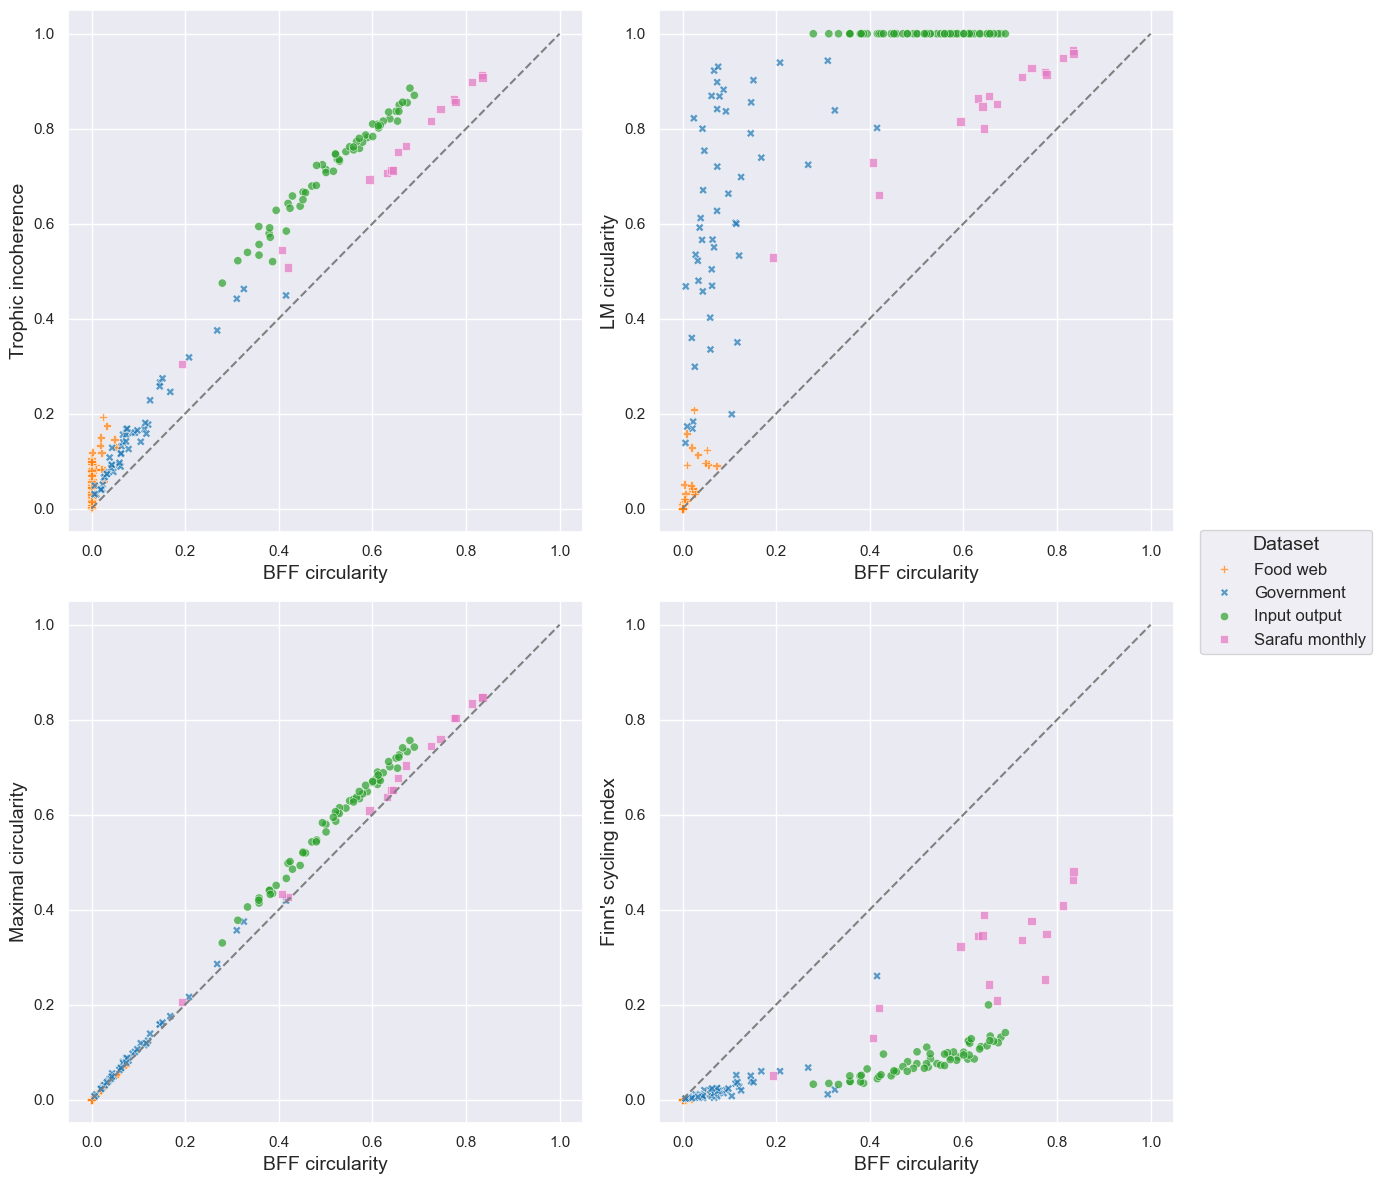

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


# Tag each dataset
df_fw['dataset'] = 'Food web'
df_government['dataset']    = 'Government'
df_io['dataset'] = 'Input output'
df_sarafu['dataset'] ='Sarafu monthly'
# Combine into one DataFrame
combined = pd.concat([df_fw,df_government, df_io,df_sarafu], ignore_index=True)
sns.set_theme(style="darkgrid")
measures = ['incoherence', 'in_cycle_ratio', 'circ_max','fci']
# measures = ['incoherence', 'in_cycle_ratio', 'circ_max']
measures_mapping= {'incoherence':'Trophic incoherence', 'in_cycle_ratio':'LM circularity', 'circ_max':'Maximal circularity','fci':"Finn's cycling index"}
palette = {'Food web':'tab:orange','Government':'tab:blue', 'Input output':'tab:green','Sarafu monthly':'tab:pink'}
markers = {"Food web": "P","Government" : "X",  "Input output": "o","Sarafu monthly":"s"}
# Create 2×2 grid of scatter plots


fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, measure in zip(axes, measures):
    sns.scatterplot(
        data=combined,
        x='circ_bff',
        y=measure,
        hue='dataset',
        style='dataset',
        palette=palette,
        alpha=0.7,
        markers = markers,
        ax=ax,
        legend=False
    )
    # y = x reference line
    ax.plot([0, 1], [0, 1], ls='--', c='gray')
    ax.set_xlim(-0.05, 1.05)
    # ax.set_ylim(-0.1, 1.01)
    ax.set_xlabel('BFF circularity', fontsize=14)
    ax.set_ylabel(measures_mapping[measure], fontsize=14)
    
# Create a single legend outside the figure
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), title='Dataset', fontsize=12, title_fontsize=14)

# Adjust layout to accommodate the external legend
fig.tight_layout(rect=[0, 0, 1, 1])  # Adjust the right margin as needed

# Save the figure
# fig.savefig('my_figure.png', dpi=300, bbox_inches='tight')